# EDA de las estaciones DAGMA sobre Cali

El DAGMA vigila la calidad del aire de Cali con una red de nueve estaciones en tierra, el SVCASC. Estas estaciones miden la concentración de contaminantes a ras de suelo, en microgramos por metro cúbico, que es lo que de verdad respira la gente. En el proyecto cumplen el papel de referencia de campo: contra ellas se mide después si el modelo acierta al reconstruir la concentración de superficie a partir del satélite.

De toda la red interesan tres gases: dióxido de nitrógeno **NO2**, dióxido de azufre **SO2** y ozono **O3**. Las estaciones miden además material particulado y variables del clima como temperatura, humedad, viento y lluvia, que quedan como contexto.

Los datos llegan por dos vías distintas. La primera es el formato propio del DAGMA, el SVCASC: medición horaria de las nueve estaciones, validada por la autoridad municipal. La segunda es el subsistema nacional del IDEAM, el SISAIRE, que reúne lo que reportan las autoridades ambientales de todo el país y lo publica en dos presentaciones, un reporte diario de SO2 y la base horaria abierta g4t8. Como las dos vías miden las mismas estaciones por caminos distintos, conviene empezar por ver qué ofrece cada una y cuál sirve de base.

## Preparación

Antes de tocar los datos dejamos listo el entorno: las herramientas, el estilo de las figuras, dónde viven los archivos, las constantes del dominio y las funciones de apoyo.

### *Importación de dependencias*

In [1]:
import json
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### *Estilo de las gráficas y semilla*

In [2]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 137
rng = np.random.default_rng(SEED)

### *Ubicación de los datos*

In [3]:
def find_root(marker="data/dagma"):
    p = Path.cwd()
    for _ in range(8):
        if (p / marker).exists():
            return p
        p = p.parent
    raise FileNotFoundError("No encuentro la raíz del proyecto.")


ROOT = find_root()
DAGMA_DIR = ROOT / "data" / "dagma"
XLSX = DAGMA_DIR / "SVCASC_FT_50-Datos_Monitores_SVCASC_2020-2025.xlsx"
CSV = DAGMA_DIR / "reporte_sisaire.csv"
G4T8_DIR = DAGMA_DIR / "dagma" / "raw"
GEOJSON = DAGMA_DIR / "dagma" / "estaciones_dagma.geojson"
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: C:\Users\mitgar14\Desktop\Ingenieria de Datos e IA - UAO\Semestre 7\Analítica\Semana #12 - #17\Proyecto


### *Constantes del dominio*

In [4]:
# Los tres gases que nos importan y un color para cada uno.
GASES = ["NO2", "SO2", "O3"]
COLOR = {"NO2": "#d62728", "SO2": "#ff7f0e", "O3": "#2ca02c"}

# El proyecto trabaja sobre los cinco años 2020 a 2024.
ANIO0, ANIO1 = 2020, 2024

# Las nueve estaciones del SVCASC (lon, lat). Son las coordenadas que el
# sistema de monitoreo adjunta a cada medición, las mismas que usan los EDA
# satelitales del panel, y caen sobre la ubicación real de cada sitio.
ESTACIONES = {
    "Base Aérea": (-76.50653649, 3.45731978),
    "ERA Obrero": (-76.51908184, 3.44759410),
    "Cañaveralejo": (-76.54961789, 3.41545841),
    "Univalle": (-76.53372474, 3.37796681),
    "Pance": (-76.53125401, 3.30449556),
    "Transitoria": (-76.49495633, 3.41717874),
    "Compartir": (-76.46657547, 3.42825808),
    "La Flora": (-76.51805771, 3.48822548),
    "La Ermita": (-76.53097834, 3.45551754),
}

# Recuadro urbano de Cali, en longitud y latitud.
BBOX = (-76.60, -76.40, 3.30, 3.55)

# Niveles máximos de la Resolución 2254 de 2017, en ug/m3, por tiempo de exposición.
NORMA = {
    "NO2": {"1 hora": 200, "anual": 60},
    "SO2": {"24 horas": 50, "1 hora": 100},
    "O3": {"8 horas": 100},
}

# Cada fuente nombra las estaciones a su manera. Las llevamos todas a un nombre común.
CANON = {
    "BASE AEREA": "Base Aérea", "CANAVERALEJO": "Cañaveralejo",
    "COMPARTIR": "Compartir", "ERA OBRERO": "ERA Obrero",
    "ERMITA": "La Ermita", "LA ERMITA": "La Ermita",
    "FLORA": "La Flora", "LA FLORA": "La Flora", "PANCE": "Pance",
    "TRANSITORIA NAVARRO": "Transitoria", "TRANSITORIA": "Transitoria",
    "UNIVALLE": "Univalle", "UNIVERSIDAD DEL VALLE": "Univalle",
}

# Hasta dónde llega lo físicamente posible. Lo que se sale de aquí no es una medición.
# El piso en -2 conserva el ruido leve de los gases y descarta los negativos más marcados.
COTAS = {
    "NO2": (-2.0, 1000.0), "SO2": (-2.0, 1000.0), "O3": (-2.0, 500.0),
    "PM25": (0.0, 1000.0), "PM10": (0.0, 2000.0),
}

### *Funciones de apoyo*

In [5]:
def fmt(n, dec=0):
    """Número al estilo local: punto para miles, coma para decimales."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def slug(s):
    """Nombre de estación sin tildes, sin guiones y en mayúsculas, para poder cruzar fuentes."""
    s = "".join(c for c in unicodedata.normalize("NFKD", str(s))
                if not unicodedata.combining(c))
    return " ".join(s.upper().replace("-", " ").replace(".", " ").split())


def media_diaria(df_gas, min_horas=18):
    """Promedio de cada día que tenga al menos 18 de las 24 horas medidas."""
    d = df_gas.copy()
    d["fecha"] = d["datetime"].dt.normalize()
    r = d.groupby(["estacion", "fecha"])["valor"].agg(media="mean", n="count").reset_index()
    return r[r["n"] >= min_horas][["estacion", "fecha", "media"]].rename(columns={"media": "valor"})


def mda8_diario(df_o3, min_horas_vent=6, min_vent=18):
    """Para el O3: el máximo del día entre las medias móviles de ocho horas."""
    salida = []
    for est, sub in df_o3.groupby("estacion"):
        s = sub.set_index("datetime")["valor"].sort_index()
        s = s[~s.index.duplicated()].asfreq("h")
        mm8 = s.rolling(8, min_periods=min_horas_vent).mean()
        por_dia = mm8.groupby(mm8.index.normalize())
        d = pd.DataFrame({"fecha": por_dia.max().index,
                          "valor": por_dia.max().values,
                          "nvent": por_dia.count().values})
        d = d[d["nvent"] >= min_vent]
        d["estacion"] = est
        salida.append(d[["estacion", "fecha", "valor"]])
    return pd.concat(salida, ignore_index=True)


def cargar_g4t8_gases():
    """Junta los archivos de la base nacional g4t8 y se queda con los tres gases.

    El g4t8 viene en formato largo, una fila por estación, variable y hora, con
    las coordenadas y la red (DAGMA o CVC) en cada registro.
    """
    cols = ["nombre_fgda", "nombre_est", "msfl_code", "med_concentracion_estandar",
            "med_fecha_inicio", "latitud", "longitud", "municipio"]
    partes = []
    for f in sorted(G4T8_DIR.glob("g4t8_*.csv")):
        d = pd.read_csv(f, usecols=cols, low_memory=False)
        partes.append(d[d["msfl_code"].isin(GASES)])
    g = pd.concat(partes, ignore_index=True)
    g["valor"] = pd.to_numeric(g["med_concentracion_estandar"], errors="coerce")
    g["datetime"] = pd.to_datetime(g["med_fecha_inicio"], errors="coerce")
    g["estacion"] = g["nombre_est"].map(lambda x: CANON.get(slug(x)))
    g = g.dropna(subset=["valor", "datetime"])
    return g[g["datetime"].dt.year.between(ANIO0, ANIO1)]

## 1. Las fuentes sobre la mesa

El archivo del SVCASC tiene una forma incómoda. Arranca con un membrete de varias filas y solo después vienen los datos, con tres renglones de encabezado que dicen, en su orden, la estación, la variable y la unidad, y con las fechas escritas en formato día y mes. Una vez reacomodado, cada columna queda identificada por su estación y su variable, y los datos quedan con una medición por fila: estación, fecha y hora, variable, valor.

In [6]:
crudo = pd.read_excel(XLSX, sheet_name=0, engine="openpyxl", header=[22, 23, 24])
triples = list(crudo.columns)
crudo.columns = [f"{a}|||{b}|||{c}" for a, b, c in triples]
crudo = crudo.rename(columns={crudo.columns[0]: "datetime"})
crudo["datetime"] = pd.to_datetime(crudo["datetime"], errors="coerce", dayfirst=True)
crudo = crudo.dropna(subset=["datetime"])

filas = []
for col, (est, var, uni) in zip(crudo.columns[1:], triples[1:]):
    est_canon = CANON.get(slug(est))
    var = str(var).strip()
    if est_canon is None or var == "Presion Baromet _NEF":
        continue
    filas.append(pd.DataFrame({
        "datetime": crudo["datetime"].values,
        "estacion": est_canon,
        "variable": var,
        "valor": pd.to_numeric(crudo[col], errors="coerce").values,
    }))

svcasc = pd.concat(filas, ignore_index=True).dropna(subset=["valor"])
svcasc = svcasc[svcasc["datetime"].dt.year.between(ANIO0, ANIO1)]

print(f"SVCASC, mediciones horarias (2020-2024):  {fmt(len(svcasc))}")
print(f"Estaciones:                               {svcasc['estacion'].nunique()}")
print(f"Variables medidas:                        {svcasc['variable'].nunique()}")
print(f"Período cubierto:                         {svcasc['datetime'].min().date()} a {svcasc['datetime'].max().date()}")

SVCASC, mediciones horarias (2020-2024):  1.435.123
Estaciones:                               9
Variables medidas:                        15
Período cubierto:                         2020-01-01 a 2024-12-31


El archivo trae mucho más que los tres gases: material particulado fino y grueso, carbono negro, sulfuro de hidrógeno y una batería de variables del clima. De aquí en adelante nos quedamos con NO2, SO2 y O3, y dejamos el resto como telón de fondo.

In [7]:
inventario = svcasc.groupby("variable")["valor"].count().sort_values(ascending=False)
print("Mediciones horarias por variable en el SVCASC:")
for v, n in inventario.items():
    marca = "  <- objetivo" if v in GASES else ""
    print(f"  {v:18s} {fmt(n):>10}{marca}")

Mediciones horarias por variable en el SVCASC:
  PM10                  247.151
  Lluvia                189.729
  O3                    179.062  <- objetivo
  SO2                   123.706  <- objetivo
  Radiacion Solar        99.206
  PM25                   97.681
  Temperatura            93.162
  Humedad                91.224
  Vel Viento             89.267
  Dir Viento             87.408
  H2S                    63.273
  Presion Baromet        42.211
  NO2                    25.158  <- objetivo
  UV-PM                   3.575
  Black Carbon            3.310


El reporte del SISAIRE es más sencillo de leer: una fila por estación y día, con el promedio de SO2 de ese día. Lo único que trae de más son unas estaciones de prueba, que no son de la red y que dejamos por fuera.

In [8]:
sisaire = pd.read_csv(CSV, encoding="utf-8").rename(
    columns={"Fecha inicial": "fecha", "SO2": "valor"})
sisaire["fecha"] = pd.to_datetime(sisaire["fecha"], errors="coerce").dt.normalize()
sisaire["estacion"] = sisaire["Estacion"].map(lambda x: CANON.get(slug(x)))

reconocidas = sisaire["estacion"].notna()
print(f"Reporte SISAIRE, filas:                 {fmt(len(sisaire))}")
print(f"De estaciones de la red:                {fmt(int(reconocidas.sum()))}")
print(f"De estaciones de prueba (descartadas):  {fmt(int((~reconocidas).sum()))}")
print(f"Rango de fechas:                        {sisaire['fecha'].min().date()} a {sisaire['fecha'].max().date()}")

Reporte SISAIRE, filas:                 9.594
De estaciones de la red:                8.547
De estaciones de prueba (descartadas):  1.047
Rango de fechas:                        2003-12-01 a 2023-09-14


La tercera pieza es la base nacional g4t8 del IDEAM, que recoge lo que reportan las autoridades ambientales del país y lo publica como datos abiertos. Trae las estaciones del DAGMA en Cali y, además, las de la CVC repartidas por el Valle del Cauca. Cargamos solo los tres gases y miramos cuánto cubre de la red de Cali frente al SVCASC.

In [9]:
g4 = cargar_g4t8_gases()
g4_dagma = g4[g4["nombre_fgda"] == "DAGMA"]
g4_cvc = g4[g4["nombre_fgda"] == "CVC"]

print(f"g4t8, registros horarios de gases (2020-2024): {fmt(len(g4))}")
print(f"  red DAGMA (Cali):        {fmt(len(g4_dagma))}")
print(f"  red CVC (Valle):         {fmt(len(g4_cvc))}")

comparacion = pd.DataFrame({
    "SVCASC": svcasc[svcasc["variable"].isin(GASES)].groupby("variable")["valor"].count(),
    "g4t8 DAGMA": g4_dagma.groupby("msfl_code")["valor"].count(),
}).reindex(GASES).fillna(0).astype(int)
print("\nHoras de cada gas en la red de Cali, por fuente:")
print(comparacion.to_string())

g4t8, registros horarios de gases (2020-2024): 247.657
  red DAGMA (Cali):        72.919
  red CVC (Valle):         174.738

Horas de cada gas en la red de Cali, por fuente:
     SVCASC  g4t8 DAGMA
NO2   25158           0
SO2  123706       28912
O3   179062       44007


Las dos fuentes de Cali no pesan igual. El SVCASC tiene varias veces más horas de O3 y de SO2 que el g4t8, y el NO2 solo aparece en el SVCASC: la base nacional no trae ese gas para ninguna estación del DAGMA. Sumado a eso, el g4t8 reporta la concentración llevada a condiciones de referencia, 25 grados y 760 milímetros de mercurio, que en Cali, a unos 900 hectopascales, queda alrededor de un diez por ciento por encima de la lectura local. Donde las dos fuentes miden la misma estación a la misma hora, sus valores se siguen poco, porque son dos versiones del mismo dato: la curada por el DAGMA y la reportada al sistema nacional. Por cobertura, por tener el NO2 y por ser el dato que el propio DAGMA valida, el SVCASC queda como fuente principal. El reporte del SISAIRE entra solo a tapar huecos de SO2, y el g4t8 sirve sobre todo para mirar el contexto regional, las estaciones de la CVC que el SVCASC no incluye.

## 2. Las estaciones en el mapa

Antes de mirar números conviene ver dónde está parada cada estación. Las nueve del DAGMA caben en el recuadro urbano de Cali, repartidas entre el norte, el centro y el sur, con Pance ya casi en el borde rural. Para un área de unos 600 kilómetros cuadrados, nueve puntos son pocos, y cada estación termina representando un pedazo grande de ciudad. Encima dibujamos las estaciones de la CVC que el g4t8 ubica cerca, hacia Yumbo y el sur rural, que sirven de referencia regional aunque queden fuera de la ciudad.

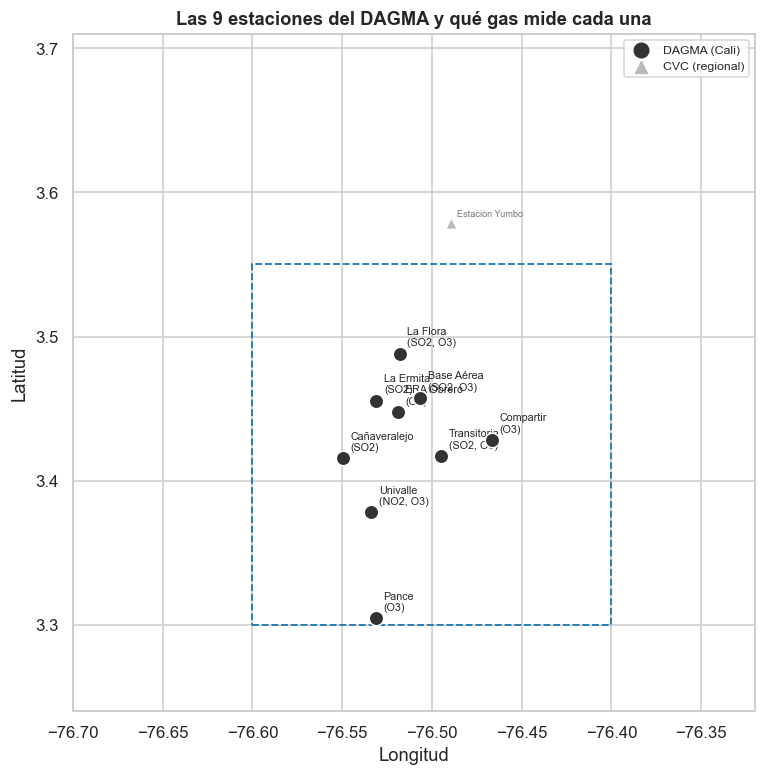

In [10]:
mide = (svcasc[svcasc["variable"].isin(GASES)]
        .groupby(["estacion", "variable"])["valor"].count().unstack(fill_value=0))

# Coordenadas de las estaciones CVC cercanas, tomadas del propio g4t8.
cvc_pts = (g4_cvc.groupby("nombre_est")[["longitud", "latitud"]].median())
cerca = cvc_pts[(cvc_pts["longitud"].between(-76.70, -76.40))
                & (cvc_pts["latitud"].between(3.20, 3.70))]

fig, ax = plt.subplots(figsize=(8, 8))
for nom, (lo, la) in ESTACIONES.items():
    gases_est = [g for g in GASES if nom in mide.index and mide.loc[nom, g] > 0]
    ax.scatter(lo, la, s=90, c="#333333", edgecolors="white", zorder=5)
    etiqueta = f"{nom}\n({', '.join(gases_est) if gases_est else 'sin gases'})"
    ax.annotate(etiqueta, (lo, la), fontsize=7, xytext=(5, 5), textcoords="offset points")
for nom, row in cerca.iterrows():
    ax.scatter(row["longitud"], row["latitud"], s=60, marker="^",
               c="#bbbbbb", edgecolors="white", zorder=4)
    ax.annotate(nom.title(), (row["longitud"], row["latitud"]), fontsize=6,
                color="#777777", xytext=(4, 4), textcoords="offset points")
ax.scatter([], [], s=90, c="#333333", label="DAGMA (Cali)")
ax.scatter([], [], s=60, marker="^", c="#bbbbbb", label="CVC (regional)")
ax.add_patch(plt.Rectangle((BBOX[0], BBOX[2]), BBOX[1] - BBOX[0], BBOX[3] - BBOX[2],
                           fill=False, ec="#1f77b4", ls="--", lw=1.2))
ax.set_xlim(BBOX[0] - 0.10, BBOX[1] + 0.08)
ax.set_ylim(BBOX[2] - 0.06, BBOX[3] + 0.16)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("Las 9 estaciones del DAGMA y qué gas mide cada una")
ax.legend(loc="upper right", fontsize=8)
plt.show()

El mapa deja ver un reparto desigual de los gases. El ozono está en casi todas, así que es el único con buena cobertura por toda la ciudad. El SO2 vive en un puñado de estaciones del centro y el norte. Y el NO2, el gas del tráfico, lo mide en serio una sola estación, Univalle, en el sur. Esa desigualdad marca todo lo que sigue.

Sobre la ubicación hay un detalle que conviene anotar. El paquete de datos trae un archivo geográfico de las estaciones cuyas coordenadas no coinciden con las que el sistema de monitoreo guarda en cada medición, con diferencias de hasta un par de kilómetros. Al contrastar ambas con sitios conocidos, la base aérea, el campus de Univalle, el barrio de Cañaveralejo en la ladera occidental, las del sistema de monitoreo caen donde deben y las del archivo geográfico aparecen corridas. Por eso usamos las del sistema de monitoreo, que además son las mismas con las que el resto del panel extrae el píxel satelital de cada estación.

## 3. Limpieza: centinelas, imposibles y negativos

Ningún sensor es perfecto, y estos archivos traen marcas de eso. Hay tres cosas distintas que filtrar. La primera son los valores centinela, números como 9.999 que el equipo escribe para decir que ahí no hubo dato; no son una medición y hay que sacarlos. La segunda son los imposibles físicos, como vientos de cientos de metros por segundo o lluvias negativas, que delatan una falla del sensor. La tercera, más delicada, son los valores un poquito por debajo de cero en los gases.

In [11]:
gas = svcasc[svcasc["variable"].isin(GASES)].copy()
n_inicial = len(gas)

centinela = int((gas["valor"] >= 9999).sum())
print(f"Mediciones marcadas como centinela (9.999 o más): {fmt(centinela)}")
print("\nValores negativos por gas:")
for g in GASES:
    v = gas.loc[gas["variable"] == g, "valor"]
    leves = int(((v >= -2) & (v < 0)).sum())
    fuertes = int((v < -2).sum())
    minimo = v.min()
    print(f"  {g}: {fmt(leves)} leves (entre -2 y 0) y {fmt(fuertes)} marcados, "
          f"el más bajo en {fmt(minimo, 2)} ug/m3")

Mediciones marcadas como centinela (9.999 o más): 0

Valores negativos por gas:
  NO2: 0 leves (entre -2 y 0) y 0 marcados, el más bajo en 0,00 ug/m3
  SO2: 44 leves (entre -2 y 0) y 16 marcados, el más bajo en -4,53 ug/m3
  O3: 0 leves (entre -2 y 0) y 0 marcados, el más bajo en 0,00 ug/m3


Un valor negativo en un gas no siempre es basura. Cuando la concentración real es muy baja, el ruido del instrumento puede dejar la lectura un poquito por debajo de cero, y borrar esos casos sesgaría todo hacia arriba, así que los que caen entre cero y el límite de detección se conservan. El NO2 y el O3 llegan sin un solo negativo. El SO2 tiene sesenta: cuarenta y cuatro leves, que se quedan, y dieciséis más marcados, que se van. Por arriba, ninguno de los tres gases trae cifras imposibles; ese problema vive en las columnas del clima, que aquí no entran al análisis.

In [12]:
for var, (lo, hi) in COTAS.items():
    m = gas["variable"] == var
    gas.loc[m & ~gas["valor"].between(lo, hi), "valor"] = np.nan
gas = gas.dropna(subset=["valor"])

print(f"Mediciones de gases antes de limpiar:  {fmt(n_inicial)}")
print(f"Mediciones de gases después:           {fmt(len(gas))}")
print(f"Descartadas:                           {fmt(n_inicial - len(gas))}")
print("\nRango que queda por gas (ug/m3):")
print(gas.groupby("variable")["valor"].agg(
    minimo="min", mediana="median", maximo="max").round(2))

Mediciones de gases antes de limpiar:  327.926
Mediciones de gases después:           327.910
Descartadas:                           16

Rango que queda por gas (ug/m3):
          minimo  mediana  maximo
variable                         
NO2         0.00    12.00   91.86
O3          0.00    15.56  290.41
SO2        -1.86     2.78  841.97


Lo que queda cae en rangos creíbles para una ciudad. El NO2 y el O3 se mueven en valores de decenas, como se espera. El SO2 deja un máximo de varios cientos, una medición real de un episodio puntual, de esos que la norma clasifica como alerta, que conviene tener en el radar sin borrarlo.

## 4. Qué tan completa es cada serie

Tener un sensor instalado no garantiza que mida todos los días. Para usar una estación como referencia hace falta saber cuántos días tiene dato de verdad. Pasamos las mediciones por hora a un valor por día, con una regla prestada de la norma europea: un día solo cuenta si tiene al menos 18 de sus 24 horas. Para el ozono usamos su métrica propia, el máximo diario del promedio móvil de ocho horas, que es como se vigila ese gas.

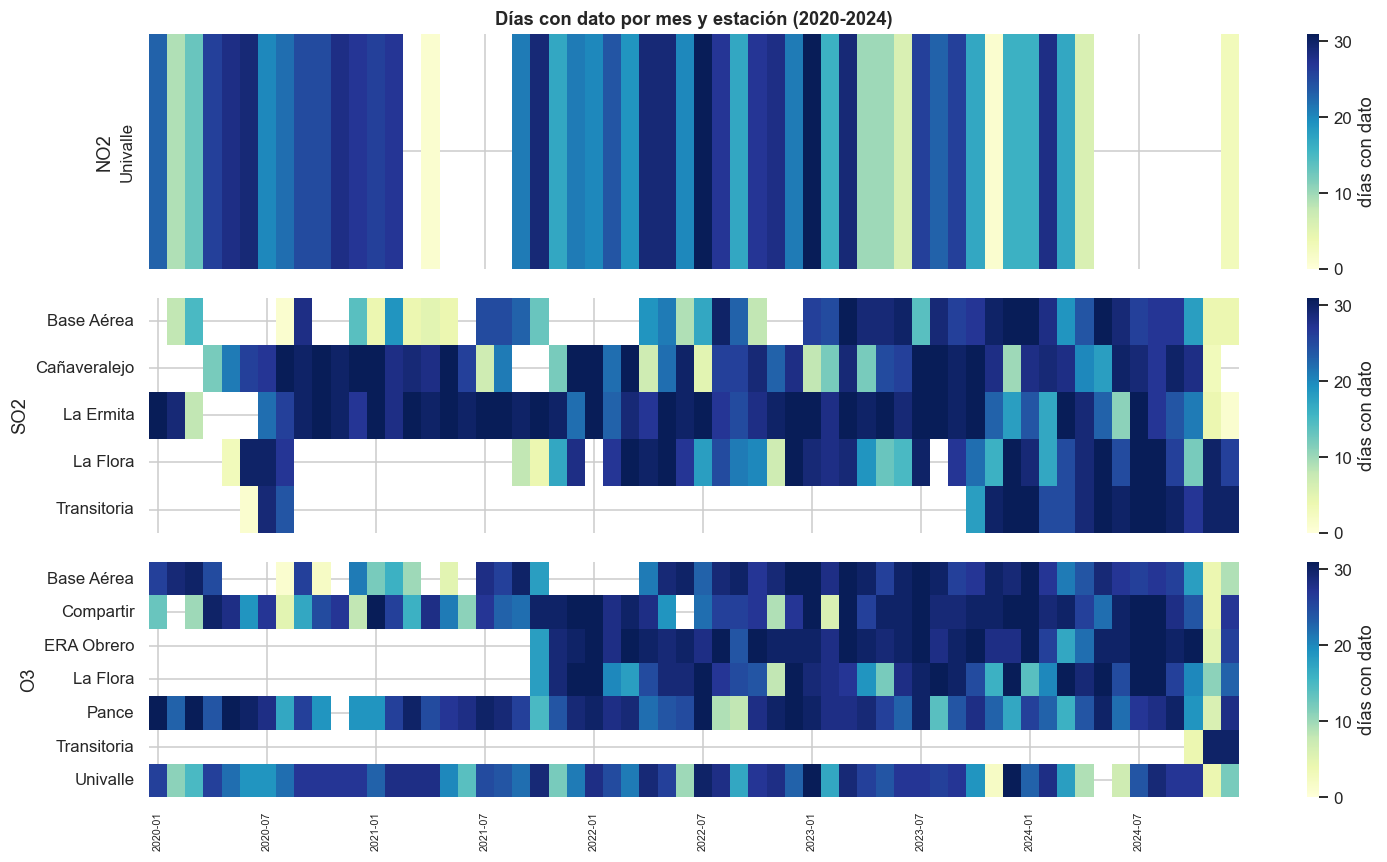

In [13]:
diario = {
    "NO2": media_diaria(gas[gas["variable"] == "NO2"]),
    "SO2": media_diaria(gas[gas["variable"] == "SO2"]),
    "O3": mda8_diario(gas[gas["variable"] == "O3"]),
}

orden_mes = pd.period_range(f"{ANIO0}-01", f"{ANIO1}-12", freq="M").astype(str)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, g in zip(axes, GASES):
    d = diario[g].copy()
    d["mes"] = d["fecha"].dt.to_period("M").astype(str)
    piv = (d.pivot_table(index="estacion", columns="mes", values="valor", aggfunc="count")
           .reindex(columns=orden_mes))
    sns.heatmap(piv, cmap="YlGnBu", ax=ax, cbar_kws={"label": "días con dato"},
                vmin=0, vmax=31)
    ax.set_ylabel(g); ax.set_xlabel("")
    ax.set_xticks(np.arange(0, len(orden_mes), 6) + 0.5)
    ax.set_xticklabels(orden_mes[::6], rotation=90, fontsize=7)
axes[0].set_title("Días con dato por mes y estación (2020-2024)")
plt.tight_layout()
plt.show()

El mapa de calor muestra lo dispar que es la cobertura. El ozono tiene franjas largas y oscuras en varias estaciones, señal de años bien medidos. El NO2 es una sola línea, la de Univalle, y ni esa está completa. El SO2 va por temporadas, con estaciones que entran y salen. Hay vacíos de meses enteros, que son fallas o mantenimientos largos y que no tiene sentido inventar.

In [14]:
dias_periodo = (pd.Timestamp(f"{ANIO1}-12-31") - pd.Timestamp(f"{ANIO0}-01-01")).days + 1
print(f"Días del período 2020-2024: {fmt(dias_periodo)}\n")
print("Porcentaje de días con dato válido por estación:")
for g in GASES:
    cob = (diario[g].groupby("estacion")["fecha"].count() / dias_periodo * 100).sort_values(ascending=False)
    print(f"\n  {g}:")
    for est, pct in cob.items():
        senal = "  ok" if pct >= 75 else ""
        print(f"    {est:14s} {fmt(pct, 1):>6} %{senal}")

Días del período 2020-2024: 1.827

Porcentaje de días con dato válido por estación:

  NO2:
    Univalle         54,2 %

  SO2:
    La Ermita        83,2 %  ok
    Cañaveralejo     71,5 %
    La Flora         54,0 %
    Base Aérea       49,8 %
    Transitoria      26,4 %

  O3:
    Pance            80,0 %  ok
    Compartir        78,0 %  ok
    Univalle         72,7 %
    Base Aérea       64,1 %
    ERA Obrero       59,9 %
    La Flora         53,3 %
    Transitoria       3,5 %


Si pedimos que una estación tenga dato al menos en tres de cada cuatro días para tomarla en serio, el panorama es sobrio. En NO2 no la pasa nadie: Univalle, la única, ronda la mitad de los días. En O3 la pasan dos, Pance y Compartir, con Univalle muy cerca. En SO2 la pasa una, La Ermita. Este es el material con el que hay que trabajar, y dice de entrada que validar el modelo gas por gas no va a tener la misma solidez en los tres.

## 5. Cómo se reparten los valores

Cada gas tiene su propia manera de repartirse. Lo vemos con la distribución de los promedios diarios, y de paso ponemos la línea de la norma para saber dónde queda Cali frente a lo permitido. Para el NO2 y el O3 comparamos contra su nivel anual y de ocho horas; para el SO2, contra el de 24 horas.

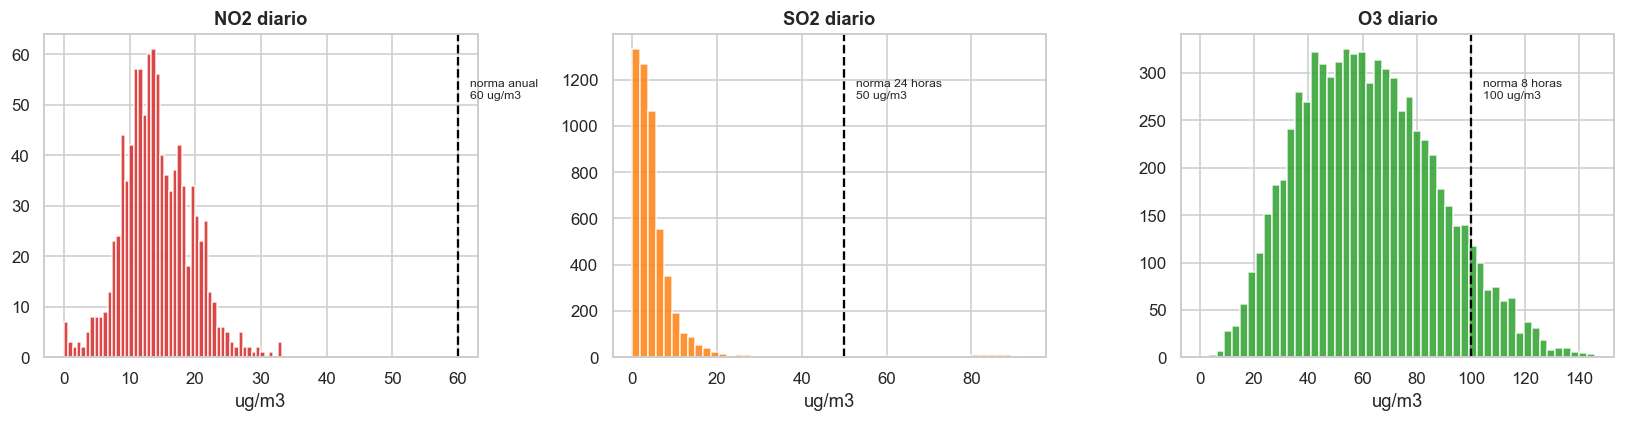

NO2: mediana 13,7 ug/m3, días sobre la norma anual (60): 0,0 %
SO2: mediana 3,7 ug/m3, días sobre la norma 24 horas (50): 1,7 %
O3: mediana 60,6 ug/m3, días sobre la norma 8 horas (100): 7,9 %


In [15]:
ref = {"NO2": ("anual", NORMA["NO2"]["anual"]),
       "SO2": ("24 horas", NORMA["SO2"]["24 horas"]),
       "O3": ("8 horas", NORMA["O3"]["8 horas"])}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, g in zip(axes, GASES):
    v = diario[g]["valor"]
    ax.hist(v, bins=50, color=COLOR[g], alpha=0.85, edgecolor="white")
    etiqueta, valor = ref[g]
    ax.axvline(valor, color="black", lw=1.5, ls="--")
    ax.annotate(f"norma {etiqueta}\n{fmt(valor)} ug/m3", (valor, ax.get_ylim()[1] * 0.8),
                xytext=(8, 0), textcoords="offset points", fontsize=8)
    ax.set_title(f"{g} diario")
    ax.set_xlabel("ug/m3")
plt.tight_layout()
plt.show()

for g in GASES:
    v = diario[g]["valor"]
    etiqueta, valor = ref[g]
    print(f"{g}: mediana {fmt(v.median(), 1)} ug/m3, "
          f"días sobre la norma {etiqueta} ({fmt(valor)}): {fmt((v > valor).mean() * 100, 1)} %")

El NO2 se queda siempre muy por debajo de su norma anual, así que a escala diaria no representa un problema en Cali. El ozono es el que más se acerca al límite, con una mediana alrededor de 60 microgramos, más de la mitad de la norma de ocho horas, y cerca del ocho por ciento de los días por encima de ella. El SO2 tiene una mediana baja, pero su distribución arrastra una cola larga con picos que pasan el límite de 24 horas en una porción menor de días. Cada gas se aparta de la norma a su manera.

## 6. El ciclo del día

Medir cada hora permite ver cómo cambia cada gas a lo largo del día. Promediamos cada hora sobre todos los días para dibujar el ciclo típico. El momento que más importa para el proyecto es la franja en que pasa el satélite, cerca de la una y media de la tarde en hora local.

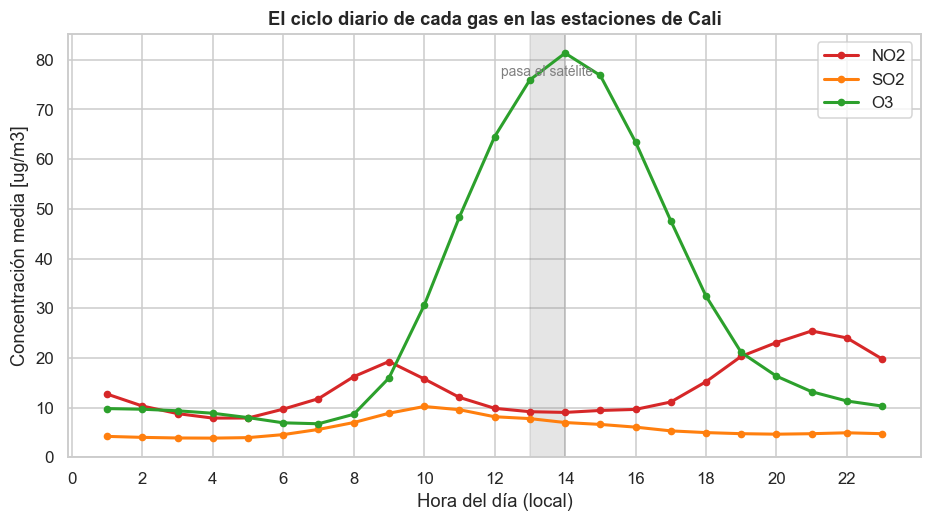

In [16]:
hora = gas.copy()
hora["h"] = hora["datetime"].dt.hour
fig, ax = plt.subplots(figsize=(10, 5))
for g in GASES:
    ciclo = hora[hora["variable"] == g].groupby("h")["valor"].mean()
    ax.plot(ciclo.index, ciclo.values, "o-", color=COLOR[g], lw=2, label=g, ms=4)
ax.axvspan(13, 14, color="gray", alpha=0.2)
ax.annotate("pasa el satélite", xy=(13.5, ax.get_ylim()[1] * 0.9),
            fontsize=9, ha="center", color="gray")
ax.set_xlabel("Hora del día (local)")
ax.set_ylabel("Concentración media [ug/m3]")
ax.set_title("El ciclo diario de cada gas en las estaciones de Cali")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.show()

El NO2 y el O3 van al revés. El NO2 tiene dos jorobas, la del trancón de la mañana y otra mayor en la noche, con un valle marcado al mediodía. El O3 hace lo contrario: necesita sol para formarse, así que sube en las horas de luz y llega a su punto alto al mediodía. El SO2 se mantiene más plano. Que el O3 tope cerca de las dos de la tarde confirma que el dato está en hora local de Cali, no en la hora universal del satélite.

In [17]:
no2u = hora[(hora["variable"] == "NO2") & (hora["estacion"] == "Univalle")]
ciclo_u = no2u.groupby("h")["valor"].mean()
print("NO2 en Univalle, promedio por hora:")
print(f"  pico de la mañana (7-9 h):   {fmt(ciclo_u.loc[7:9].mean(), 1)} ug/m3")
print(f"  valle del mediodía (13-14):  {fmt(ciclo_u.loc[13:14].mean(), 1)} ug/m3")
print(f"  pico de la noche (19-21 h):  {fmt(ciclo_u.loc[19:21].mean(), 1)} ug/m3")

NO2 en Univalle, promedio por hora:
  pico de la mañana (7-9 h):   15,8 ug/m3
  valle del mediodía (13-14):  9,1 ug/m3
  pico de la noche (19-21 h):  22,9 ug/m3


El satélite retrata el NO2 a la una y media de la tarde, el momento más bajo del día, mientras la gente respira lo peor en los picos de la mañana y la noche. La diferencia es grande: el valle del mediodía es menos de la mitad del pico nocturno. Por eso pedirle al satélite que estime el aire del suelo es difícil, y por eso el dato de tierra hora a hora vale tanto para corregir esa visión parcial.

## 7. La historia en el tiempo

Con los promedios diarios armamos la serie de cada gas a lo largo de los cinco años. Para que el ruido del día a día no tape la tendencia, dibujamos encima una línea suave de un mes. Promediamos las estaciones disponibles de cada gas, de modo que la línea resume el comportamiento de la ciudad.

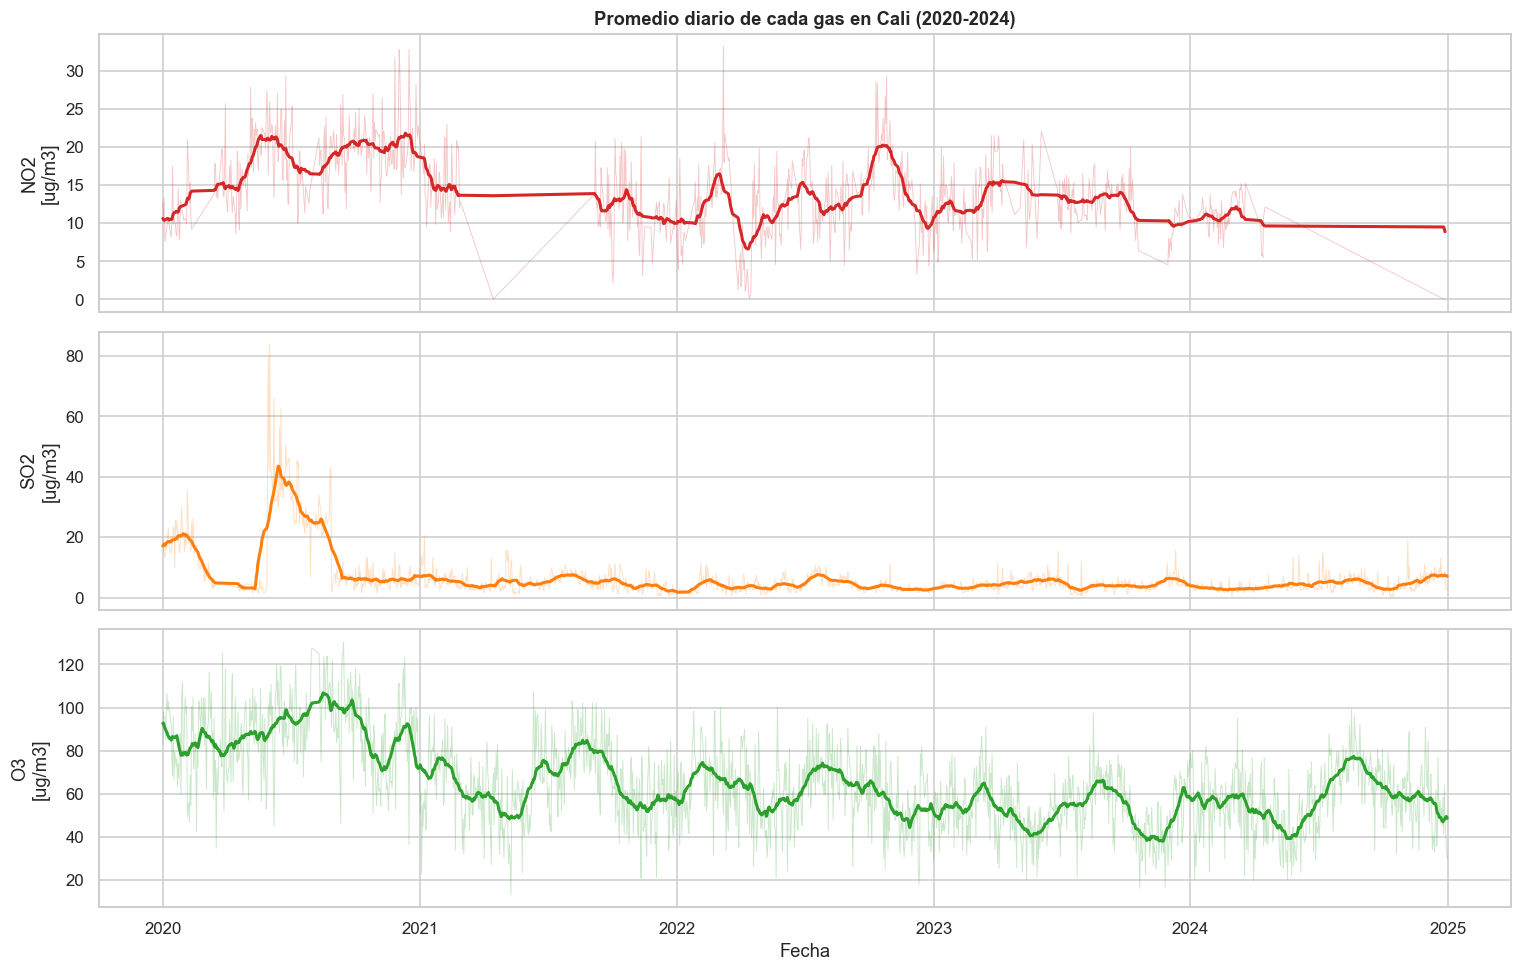

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, g in zip(axes, GASES):
    serie = diario[g].groupby("fecha")["valor"].mean().sort_index()
    ax.plot(serie.index, serie.values, color=COLOR[g], alpha=0.25, lw=0.6)
    ax.plot(serie.index, serie.rolling(30, min_periods=10, center=True).mean(),
            color=COLOR[g], lw=2)
    ax.set_ylabel(f"{g}\n[ug/m3]")
axes[0].set_title("Promedio diario de cada gas en Cali (2020-2024)")
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

El ozono es el más estable y deja ver un vaivén estacional suave, atado a las temporadas de sol y lluvia. El NO2 de Univalle se mantiene en un rango parecido todos los años, sin grandes saltos. El SO2 es el más irregular, con tramos sueltos y picos que coinciden con los episodios que ya habían aparecido en la distribución.

## 8. El SO2 visto por tres canales

El SO2 es el único gas que aparece en las tres fuentes, así que sirve para ver qué tanto concuerdan. El SVCASC lo mide por hora en cinco estaciones; el reporte del SISAIRE trae un promedio diario que alcanza algunas fechas que al SVCASC le faltan; y el g4t8 lo trae por hora desde la base nacional. La regla para consolidar es conservadora: manda el dato horario del SVCASC, porque es el que valida el DAGMA, y el reporte diario del SISAIRE solo rellena los días en que el SVCASC no tiene nada. Cada valor queda marcado con su procedencia.

In [19]:
sisaire_so2 = (sisaire.dropna(subset=["estacion", "fecha"])
               .query("valor < 9999 and valor >= -10")
               .loc[lambda d: d["fecha"].dt.year.between(ANIO0, ANIO1)]
               [["estacion", "fecha", "valor"]]
               .drop_duplicates(["estacion", "fecha"]))

so2_svcasc = diario["SO2"].assign(fuente="SVCASC horario")
clave_svcasc = so2_svcasc.set_index(["estacion", "fecha"]).index
solo_sisaire = (sisaire_so2.assign(fuente="SISAIRE diario")
                .loc[lambda d: ~d.set_index(["estacion", "fecha"]).index.isin(clave_svcasc)])
so2_total = pd.concat([so2_svcasc, solo_sisaire], ignore_index=True)

aporte = so2_total.groupby("fuente")["fecha"].count()
print("Días de SO2 que aporta cada fuente al panel consolidado:")
for f, n in aporte.items():
    print(f"  {f:16s} {fmt(n):>7}")
print(f"\nDías de SO2 que el reporte diario rescata y el horario no tenía: {fmt(len(solo_sisaire))}")

Días de SO2 que aporta cada fuente al panel consolidado:
  SISAIRE diario       979
  SVCASC horario     5.205

Días de SO2 que el reporte diario rescata y el horario no tenía: 979


El reporte diario rescata cerca de mil días de SO2 que el SVCASC no cubre, repartidos entre las cinco estaciones que ya miden el gas, sobre todo Base Aérea y La Flora. No añade estaciones nuevas para el período del proyecto, porque el SO2 que el reporte tenía de otras estaciones queda en años anteriores a 2020. Es un complemento que recupera cobertura sin costo.

In [20]:
# Concordancia entre las dos versiones horarias del mismo gas: SVCASC y g4t8.
g4_so2 = (g4_dagma[g4_dagma["msfl_code"] == "SO2"]
          .assign(fecha=lambda d: d["datetime"].dt.normalize())
          .groupby(["estacion", "fecha"])["valor"].mean().reset_index())
comun = so2_svcasc.merge(g4_so2, on=["estacion", "fecha"], suffixes=("_svcasc", "_g4t8"))
print(f"Días en que el SVCASC y el g4t8 miden la misma estación: {fmt(len(comun))}\n")
print("Qué tanto concuerdan, estación por estación:")
for est, sub in comun.groupby("estacion"):
    if len(sub) >= 30:
        r = np.corrcoef(sub["valor_svcasc"], sub["valor_g4t8"])[0, 1]
        sesgo = (sub["valor_svcasc"] - sub["valor_g4t8"]).mean()
        print(f"  {est:12s} n={fmt(len(sub)):>5}, correlación {fmt(r, 2):>6}, "
              f"diferencia media {fmt(sesgo, 1):>6} ug/m3")

Días en que el SVCASC y el g4t8 miden la misma estación: 830

Qué tanto concuerdan, estación por estación:
  Base Aérea   n=  168, correlación   0,16, diferencia media   -0,5 ug/m3
  Cañaveralejo n=  242, correlación  -0,56, diferencia media    2,8 ug/m3
  La Ermita    n=  347, correlación   0,12, diferencia media    5,3 ug/m3
  La Flora     n=   34, correlación   0,21, diferencia media   73,6 ug/m3
  Transitoria  n=   39, correlación   0,02, diferencia media   -5,2 ug/m3


La comparación confirma lo que ya aparecía al inventariar las fuentes: las dos versiones horarias del SO2 apenas se siguen. La correlación día a día es baja, en una estación incluso negativa, y las diferencias medias llegan a ser grandes. Parte viene de la naturaleza del SO2, que sobre Cali es bajo y ruidoso, cerca del límite que el instrumento alcanza a distinguir, y parte de que el dato curado por el DAGMA y el reportado al sistema nacional pasan por validaciones distintas. El SO2 queda como la referencia más frágil de las tres, y conviene tratar sus números con cuidado y desde una sola fuente.

## 9. Lo que llega a la validación

La validación del modelo deja una estación por fuera cada vez y mide qué tan bien la reconstruye con las demás. Para que esa prueba sea sólida hacen falta varias estaciones con series largas y limpias del gas en cuestión. Juntamos la cuenta final de días útiles por gas y estación, ya con las dos fuentes de SO2 sumadas.

In [21]:
final = {"NO2": diario["NO2"], "O3": diario["O3"], "SO2": so2_total}
resumen = []
for g in GASES:
    cob = final[g].groupby("estacion")["fecha"].count()
    resumen.append({
        "gas": g,
        "estaciones con dato": len(cob),
        "estaciones sobre 75% de días": int((cob / dias_periodo >= 0.75).sum()),
        "días útiles (total)": int(cob.sum()),
    })
print(pd.DataFrame(resumen).to_string(index=False))

gas  estaciones con dato  estaciones sobre 75% de días  días útiles (total)
NO2                    1                             0                  990
SO2                    5                             2                 6184
 O3                    7                             2                 7518


Los tres gases llegan a la validación en condiciones muy distintas. El O3 queda mejor, con siete estaciones repartidas por la ciudad y dos sobre el umbral de cobertura, lo que permite una prueba espacial decente. El SO2 tiene cinco estaciones, y dos superan el umbral una vez sumado el complemento del SISAIRE, La Ermita y Cañaveralejo, aunque sus números siguen siendo frágiles. El NO2, el gas que más le importa a una ciudad por el tráfico, depende de una sola estación, así que su validación espacial servirá apenas de referencia, sin alcanzar una prueba de fondo. Tenerlo presente evita prometer una validación que el dato de tierra no puede sostener.

## Lo que nos llevamos

Las estaciones del DAGMA son la referencia de campo del proyecto, con su valor y sus límites. La medición horaria del SVCASC es la fuente principal, porque tiene la mejor cobertura, es la única con NO2 y es la que valida la propia autoridad municipal; el reporte del SISAIRE le tapa unos huecos de SO2 y la base nacional g4t8 aporta el contexto regional de la CVC, sin que ninguna de las dos sustituya al dato curado. La limpieza saca centinelas e imposibles y conserva los negativos pequeños, que son ruido legítimo. De los tres gases, el ozono llega completo y bien repartido y es el que más se acerca a la norma; el SO2 es escaso y ruidoso, con versiones que apenas concuerdan entre sí; y el NO2 cuelga de una sola estación, Univalle. El desfase del reloj condiciona buena parte de la tarea que viene: el satélite pasa al mediodía, en el valle del NO2, mientras la ciudad respira lo peor en los picos de la mañana y la noche. Esa distancia entre lo que ve el satélite y lo que mide el suelo es la que el modelo tiene que aprender a salvar.